# Used already Pre-processed dataset

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv('./data/processed/cleaned_data.csv')
data.head()

,review,sentiment
0,one reviewers mention watch oz episode hook ri...,positive
1,wonderful little production film technique ver...,positive
2,think wonderful way spend time too hot summer ...,positive
3,basically family little boy jake think zombie ...,negative
4,petter matteis love time money visually stun f...,positive


In [ ]:
data.shape

(50000, 2)

In [ ]:
data.tail()

,review,sentiment
49995,think movie right good job not creative origin...,positive
49996,bad plot bad dialogue bad act idiotic direct a...,negative
49997,catholic teach parochial elementary school nun...,negative
49998,go disagree previous comment side maltin one s...,negative
49999,no one expect star trek movies high art but fa...,negative


In [ ]:
data['sentiment'].unique()

array(['positive', 'negative'], dtype=object)

# Vectorization(Tokenizing)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

max_words = 10000  # top 10,000 most frequent words

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")

In [ ]:
# Teach the tokenizer your cleaned text
tokenizer.fit_on_texts(data['review'])

In [ ]:
# Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(data['review'])

In [ ]:
# Create a dictionary where {index: word}
reverse_word_map = {index: word for word, index in tokenizer.word_index.items()}

In [ ]:
def decode_review(sequence):
    # We use .get(i, '?') so that if an index isn't found, it returns a '?'
    # We skip 0 because 0 is usually the padding character
    return " ".join([reverse_word_map.get(i, '?') for i in sequence if i != 0])


In [ ]:
sample_sequence = sequences[10]
print("Original Sequence:", sample_sequence)
print("Reconstructed Text:", decode_review(sample_sequence))

Original Sequence: [3744, 712, 6, 2197, 3, 267, 313, 104, 1, 189, 165, 672, 1, 38, 16, 894, 100, 81, 5, 4, 1791, 2, 43, 308, 1, 81, 1, 306, 249, 3, 53, 353, 100, 70, 15, 5, 726, 199, 1, 582, 3, 14, 738, 8524, 3045, 1, 66, 623, 5, 59, 54, 539, 82, 1133]
Reconstructed Text: phil alien one quirky film humor base around <OOV> everything rather actual <OOV> first very odd pretty funny but movie progress not find joke <OOV> funny <OOV> low budget film never problem pretty interest character but eventually lose <OOV> imagine film would appeal stoner currently <OOV> something similar but better try brother another planet


# Pad Sequences

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Based on your histogram, 250 is the "Sweet Spot"
X = pad_sequences(sequences, maxlen=250,
                  padding='pre',      # RNNs remember the end better
                  truncating='pre'    # Keeps the 'conclusion' of long reviews
                  )

print("Shape of data tensor:", X.shape)

Shape of data tensor: (50000, 250)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
le = LabelEncoder()

# Fit and transform your labels
# Assuming data['sentiment'] contains ['positive', 'negative'...]
y = le.fit_transform(data['sentiment'])

# To see which number represents which class:
print(f"Classes: {le.classes_}")
print(f"Encoded labels: {y[:5]}")

Classes: ['negative' 'positive']
Encoded labels: [1 1 1 0 1]


# Split into train and test

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [ ]:
X_train

array([[   0,    0,    0, ..., 4072, 5085,   76],
       [   0,    0,    0, ..., 5896,  779, 7335],
       [   0,    0,    0, ...,    4,  134,   12],
       ...,
       [   0,    0,    0, ...,    2, 2040, 2922],
       [   0,    0,    0, ...,  750,    3,  125],
       [   0,    0,    0, ...,   27,  455,  198]], dtype=int32)

# Hyperparameter Tuning Code

In [ ]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.7 MB/s eta 0:00:00


In [ ]:
import keras
from keras import layers
import keras_tuner as kt
import tensorflow as tf

def build_model(hp):
    model = keras.Sequential()

    # 1. TUNE EMBEDDING DIMENSION
    hp_embed_dim = hp.Int('embed_dim', min_value=32, max_value=128, step=16)
    model.add(layers.Embedding(input_dim=10000, output_dim=hp_embed_dim, input_length=250))

    # 2. TUNE NUMBER OF RNN LAYERS (1 to 3)
    num_rnn_layers = hp.Int("num_rnn_layers", 1, 3)

    for i in range(num_rnn_layers):

        # Check if last layer
        is_last = (i == num_rnn_layers - 1)

        # 2. TUNE UNITS
        hp_units = hp.Int(f"units_{i}", min_value=16, max_value=128, step=16)

        # 3. TUNE WEIGHT INITIALIZATION
        hp_initializer = hp.Choice(
            f'weight_init_{i}',
            values=['glorot_uniform', 'he_normal', 'he_uniform']
        )

        # 4.  TUNE ACTIVATION
        hp_activation = hp.Choice(
            f"rnn_activation_{i}",
            values=["tanh", "relu"]
        )


        # 5. ADD SimpleRNN
        model.add(layers.SimpleRNN(
            units=hp_units,
            kernel_initializer=hp_initializer,
            return_sequences=not is_last,
            activation=hp_activation
        ))

        # 6. TUNE DROPOUT
        hp_dropout = hp.Float(f"dropout_{i}", min_value=0.0, max_value=0.5, step=0.1)
        model.add(layers.Dropout(rate=hp_dropout))

    # Output Layer
    model.add(layers.Dense(1, activation='sigmoid'))

    # 7. TUNE OPTIMIZER
    hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop'])

    # 8. LEARNING RATE
    hp_lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    if hp_optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=hp_lr)
    elif hp_optimizer == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=hp_lr, momentum=0.9)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=hp_lr)

    model.compile(
            optimizer=opt,
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
        )

    return model

In [ ]:
# INITIALIZE THE HYPERBAND
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=5,
    factor=3,
    directory='adv_tuning',
    project_name='dynamic_rnn'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# RUN THE SEARCH
tuner.search(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test, y_test),

    # 9. TUNE BATCH SIZE
    batch_size=tuner.oracle.hyperparameters.Int('batch_size', 16, 128, step=16)
)

Trial 10 Complete [00h 20m 27s]
val_accuracy: 0.8934999704360962

Best val_accuracy So Far: 0.8934999704360962
Total elapsed time: 01h 48m 42s


In [ ]:
tuner.search_space_summary()

Search space summary
Default search space size: 17
embed_dim (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
num_rnn_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
weight_init_0 (Choice)
{'default': 'glorot_uniform', 'conditions': [], 'values': ['glorot_uniform', 'he_normal', 'he_uniform'], 'ordered': False}
rnn_activation_0 (Choice)
{'default': 'tanh', 'conditions': [], 'values': ['tanh', 'relu'], 'ordered': False}
dropout_0 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'sgd', 'rmsprop'], 'ordered': False}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 

In [ ]:
tuner.results_summary()

Results summary
Results in adv_tuning/dynamic_rnn
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0009 summary
Hyperparameters:
embed_dim: 48
num_rnn_layers: 3
units_0: 96
weight_init_0: he_uniform
rnn_activation_0: relu
dropout_0: 0.30000000000000004
optimizer: rmsprop
learning_rate: 0.00010473593379759068
batch_size: 80
units_1: 80
weight_init_1: he_normal
rnn_activation_1: tanh
dropout_1: 0.2
units_2: 112
weight_init_2: he_uniform
rnn_activation_2: tanh
dropout_2: 0.1
tuner/epochs: 5
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.8934999704360962

Trial 0005 summary
Hyperparameters:
embed_dim: 112
num_rnn_layers: 2
units_0: 96
weight_init_0: glorot_uniform
rnn_activation_0: relu
dropout_0: 0.2
optimizer: rmsprop
learning_rate: 0.00029162547269851575
batch_size: 128
units_1: 48
weight_init_1: he_uniform
rnn_activation_1: relu
dropout_1: 0.1
units_2: 128
weight_init_2: he_uniform
rnn_activation_2: tanh
dropout_2: 0.0
tuner/epochs: 5
tuner

In [ ]:
# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_hps.values

{'embed_dim': 48,
 'num_rnn_layers': 3,
 'units_0': 96,
 'weight_init_0': 'he_uniform',
 'rnn_activation_0': 'relu',
 'dropout_0': 0.30000000000000004,
 'optimizer': 'rmsprop',
 'learning_rate': 0.00010473593379759068,
 'batch_size': 80,
 'units_1': 80,
 'weight_init_1': 'he_normal',
 'rnn_activation_1': 'tanh',
 'dropout_1': 0.2,
 'units_2': 112,
 'weight_init_2': 'he_uniform',
 'rnn_activation_2': 'tanh',
 'dropout_2': 0.1,
 'tuner/epochs': 5,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 0,
 'tuner/round': 0}

In [ ]:
# Get the best models
model = tuner.get_best_models(num_models=1)[0]
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (16, 250, 48)          │       480,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (16, 250, 96)          │        13,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (16, 250, 96)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (16, 250, 80)          │        14,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (16, 250, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (16, 112)              │        21,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (16, 112)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (16, 1)                │           113 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,809 (2.02 MB)

 Trainable params: 529,809 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Save the Best model by Hyperparameter
model.save('./models/best_sentiment_rnn_model.keras')

# Build the model with the winning settings

In [ ]:
final_model = tuner.hypermodel.build(best_hps)
# Pass a dummy batch or just one sample of your training data
final_model.build(input_shape=(None, 250))

final_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 250, 48)        │       480,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 250, 96)        │        13,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 250, 96)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 250, 80)        │        14,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 250, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ (None, 112)            │        21,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 112)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           113 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,809 (2.02 MB)

 Trainable params: 529,809 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
# Define the EarlyStopping monitor
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,              # Wait for 5 epochs of no improvement
    restore_best_weights=True
)

In [ ]:
# Train the model

history = final_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=80,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 109s 213ms/step - accuracy: 0.5871 - loss: 0.6577 - precision_2: 0.5884 - recall_2: 0.5858 - val_accuracy: 0.7296 - val_loss: 0.5886 - val_precision_2: 0.6624 - val_recall_2: 0.9266
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 201ms/step - accuracy: 0.8219 - loss: 0.4035 - precision_2: 0.8164 - recall_2: 0.8317 - val_accuracy: 0.8485 - val_loss: 0.3761 - val_precision_2: 0.8083 - val_recall_2: 0.9102
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 99s 198ms/step - accuracy: 0.8737 - loss: 0.3099 - precision_2: 0.8703 - recall_2: 0.8789 - val_accuracy: 0.8745 - val_loss: 0.3067 - val_precision_2: 0.8404 - val_recall_2: 0.9219
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 105s 209ms/step - accuracy: 0.8949 - loss: 0.2650 - precision_2: 0.8925 - recall_2: 0.8983 - val_accuracy: 0.8770 - val_loss: 0.3104 - val_precision_2: 0.8333 - val_recall_2: 0.9399
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 207ms/step - accuracy: 0.9093 - loss: 0.2331 - precision_2: 0.9079 -

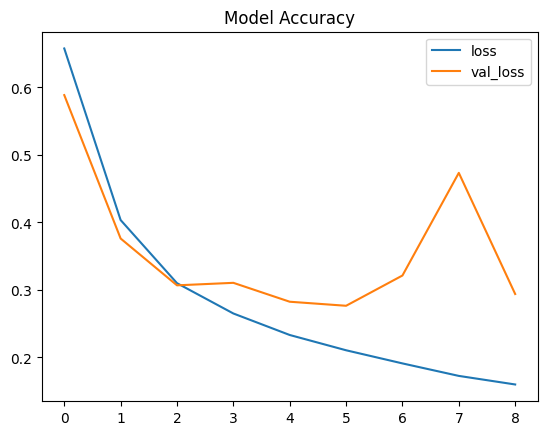

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Accuracy')
plt.legend()
plt.show()

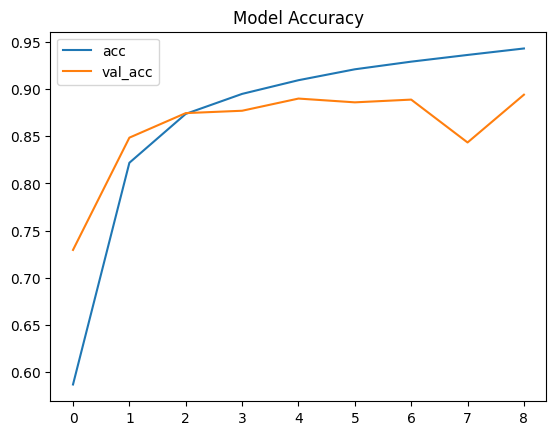

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()

In [ ]:
# Save the Best model by Hyperparameter
final_model.save('./models/sentiment_deep_rnn.keras.keras')